In [42]:
import sys
sys.path.append("../../")

# Force reload of modules to pick up the fix
if 'Classes.Persistence' in sys.modules:
    del sys.modules['Classes.Persistence']
if 'Classes.Solution' in sys.modules:
    del sys.modules['Classes.Solution']

from Classes.Solution import Solution
from Classes.Persistence import PersistMultipleSolutions, PersistSingleSolution
from Classes.utils import boxplot_fx, boxplot_convergence, get_fx_samples
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np

solution = PersistMultipleSolutions().load(filename="vns_1600", filepath="./results/")
solution_basic = PersistMultipleSolutions().load(filename="vnsbasic_1600", filepath="./results/")
optimum = PersistSingleSolution().load(filename="globopt_1600", filepath="../global_optimum/results/")

In [43]:
# Check the structure of the solutions
print(f"Type of solutions: {type(solution)}")
print(f"Number of VNS algorithms: {len(solution)}")
print(f"Shape: {len(solution)} algorithms x {len(solution[0])} instances x {len(solution[0][0])} runs")

# Check a sample solution
print(f"\nSample objective value: {solution[0][0][0].FX}")

Type of solutions: <class 'list'>
Number of VNS algorithms: 1
Shape: 1 algorithms x 1 instances x 30 runs

Sample objective value: 569346640.5766757


Total VNS algorithms: 2
Names: ['1', '2']


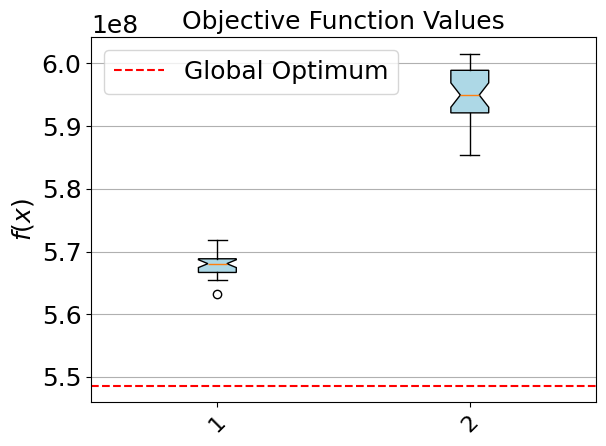

In [44]:
solutions = solution + solution_basic
names = [f"{i+1}" for i in range(len(solutions))]
print(f"Total VNS algorithms: {len(solutions)}")
print(f"Names: {names}")
boxplot_fx(solutions, names, global_optimum=optimum)

In [45]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
fx = get_fx_samples(solutions)
fx = [fx[0], fx[1]]

# Test for normality
print("Shapiro-Wilk Test p-values:")
p_values = []
for i in range(len(fx)):
    stat, p = shapiro(fx[i])
    p_values.append(p)
    print(f"Algorithm {i+1}: {p}")

# Check if both samples are normally distributed (p > 0.05)
alpha = 0.05
both_normal = all(p > alpha for p in p_values)

print(f"\nBoth samples normally distributed: {both_normal}")

# Choose appropriate test
if both_normal:
    print("\nUsing parametric t-test:")
    stat, p = ttest_ind(fx[0], fx[1], equal_var=False, alternative='less')
    print(f"T-test p-value: {p}")
else:
    print("\nUsing non-parametric Mann-Whitney U test:")
    stat, p = mannwhitneyu(fx[0], fx[1], alternative='less')
    print(f"Mann-Whitney U test p-value: {p}")

# Interpret result
if p < alpha:
    print("Result: Algorithm 1 is significantly better than Algorithm 2 (p < 0.05)")
else:
    print("Result: No significant difference between algorithms (p >= 0.05)")

Shapiro-Wilk Test p-values:
Algorithm 1: 0.3556130826484133
Algorithm 2: 0.3454115403705079

Both samples normally distributed: True

Using parametric t-test:
T-test p-value: 5.894187035340409e-31
Result: Algorithm 1 is significantly better than Algorithm 2 (p < 0.05)


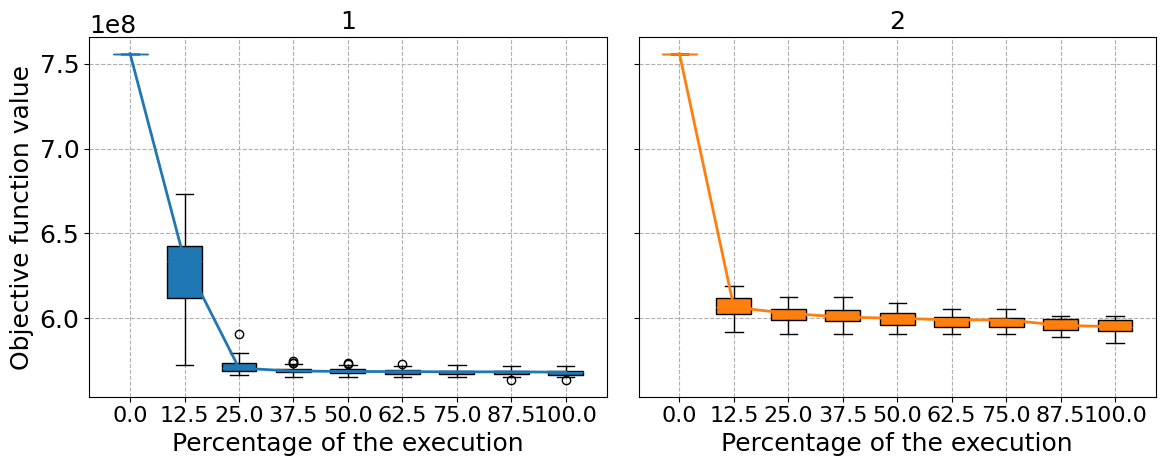

In [46]:
boxplot_convergence(solutions, names)